In [1]:
# Ячейка № 1

# моделирование движения
# нерелятивистского электрического заряда
# в скрещенных электрическом и магнитном полях

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание безразмерного вектора
# напряженности магнитного поля
B = np.array([0, 0, 1])

# задание безразмерного вектора
# напряженности электрического поля
E = np.array([0, 0.001, 0.001])


# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в левой части системы (6.43)
def Force(t, z):
    # задание глобальных переменных
    global B, E

    # инициализация массива F
    F = np.zeros(6)

    # вычисление координат вектора-функции,
    # стоящей в правой части (6.43)
    F[0] = z[1]
    F[1] = 2 * np.pi * (E[0] + (B[2] * z[3] - B[1] * z[5]))
    F[2] = z[3]
    F[3] = 2 * np.pi * (E[1] - (B[2] * z[1] - B[0] * z[5]))
    F[4] = z[5]
    F[5] = 2 * np.pi * (E[2] + (B[1] * z[1] - B[0] * z[3]))

    return F

In [3]:
# Ячейка № 3

# задание начальных условий СДУ (6.43):

# задание значения абсциссы
# радиуса-вектора в момент времени t = 0
x0 = 0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
y0 = 0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
z0 = 0

# задание значения проекции
# скорости заряда
# на ось OX  в момент времени t = 0
vx0 = 0.1

# задание значения проекции
# скорости заряда
# на ось OY  в момент времени t = 0
vy0 = 0

# задание значения проекции
# скорости заряда
# на ось OZ  в момент времени t = 0
vz0 = 0.01

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.43)
Tmax = 30

# задание максимального значения шага
# интегрирования СДУ(6.43)
dt = Tmax / 10**4

# вычисление численного решения СДУ (6.43)
Solv = solve_ivp(Force, [0, Tmax], [x0, vx0, y0, vy0, z0, vz0], max_step=dt)

# вычисление числа узлов временной сетки,
# в узлах которой вычислено численное решение
# СДУ (6.43)
N = len(Solv.t)

# инициализация массива mod_V,
# используемого для хранения
# модуля скорости заряда
mod_V = np.zeros(N)

# вычисление значений зависимости
# модуля скорости от времени
mod_V[:] = np.sqrt(Solv.y[1, :] ** 2 + Solv.y[3, :] ** 2 + Solv.y[5, :] ** 2)


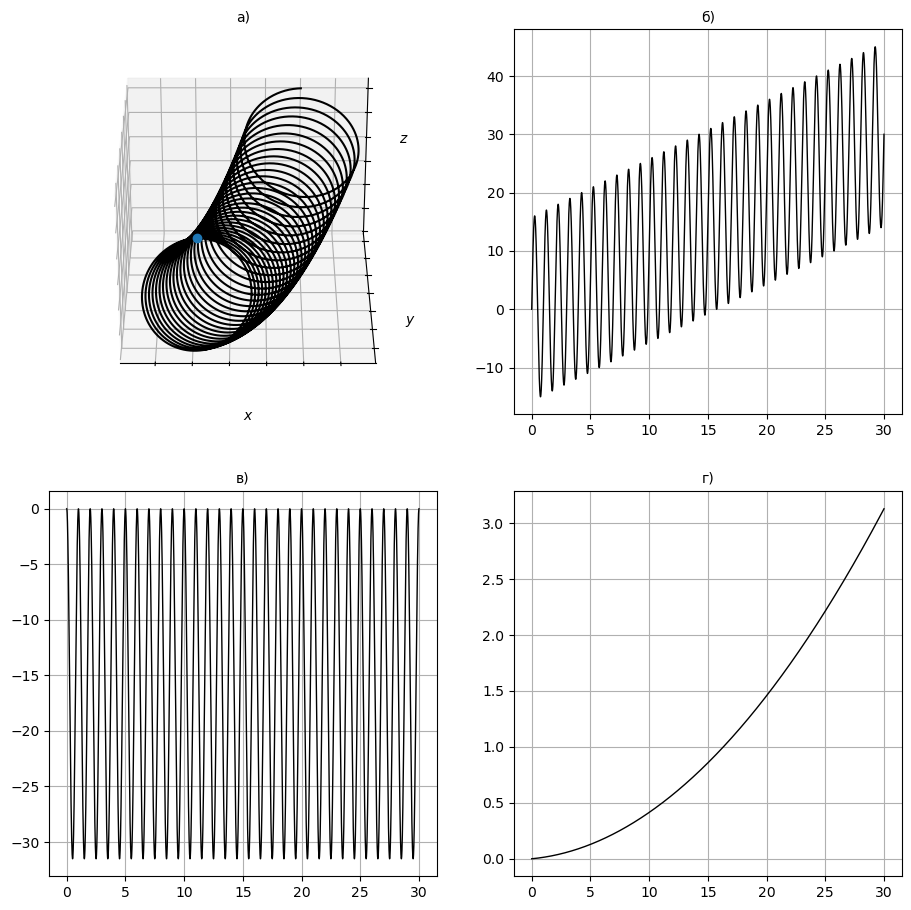

In [4]:
# Ячейка № 4

# визуализация траектории заряда и
# зависимостей его координат о времени

fig = plt.figure(figsize=(11, 11))
# визуализация траектории заряда
ax = fig.add_subplot(2, 2, 1, projection="3d")
ax.plot3D(Solv.y[0, :], Solv.y[2, :], Solv.y[4, :], "black")
ax.view_init(30, -90)
ax.grid(True)

# отключение нумерации делений
# координатной сетки
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# визуализация начального положения заряда
ax.plot3D(x0, y0, z0, "o")
ax.set_title("а)", fontsize=10)
ax.set_xlabel(r"$x$", fontsize=10)
ax.set_ylabel(r"$y$", fontsize=10)
ax.set_zlabel(r"$z$", fontsize=10)


# визуализация зависимости x = x(t)
ax = fig.add_subplot(2, 2, 2)
ax.plot(Solv.t[:], Solv.y[0, :] * 10**3, "-k", lw=1)
ax.grid(True)
ax.set_title(r"б)", fontsize=10)

# визуализация зависимости y = y(t)
ax = fig.add_subplot(2, 2, 3)
ax.plot(Solv.t[:], Solv.y[2, :] * 10**3, "-k", lw=1)
ax.grid(True)
ax.set_title(r"в)", fontsize=10)

# визуализация зависимости z = z(t)
ax = fig.add_subplot(2, 2, 4)
ax.plot(Solv.t[:], Solv.y[4, :], "-k", lw=1)
ax.grid(True)
ax.set_title(r"г)", fontsize=10)

plt.show()


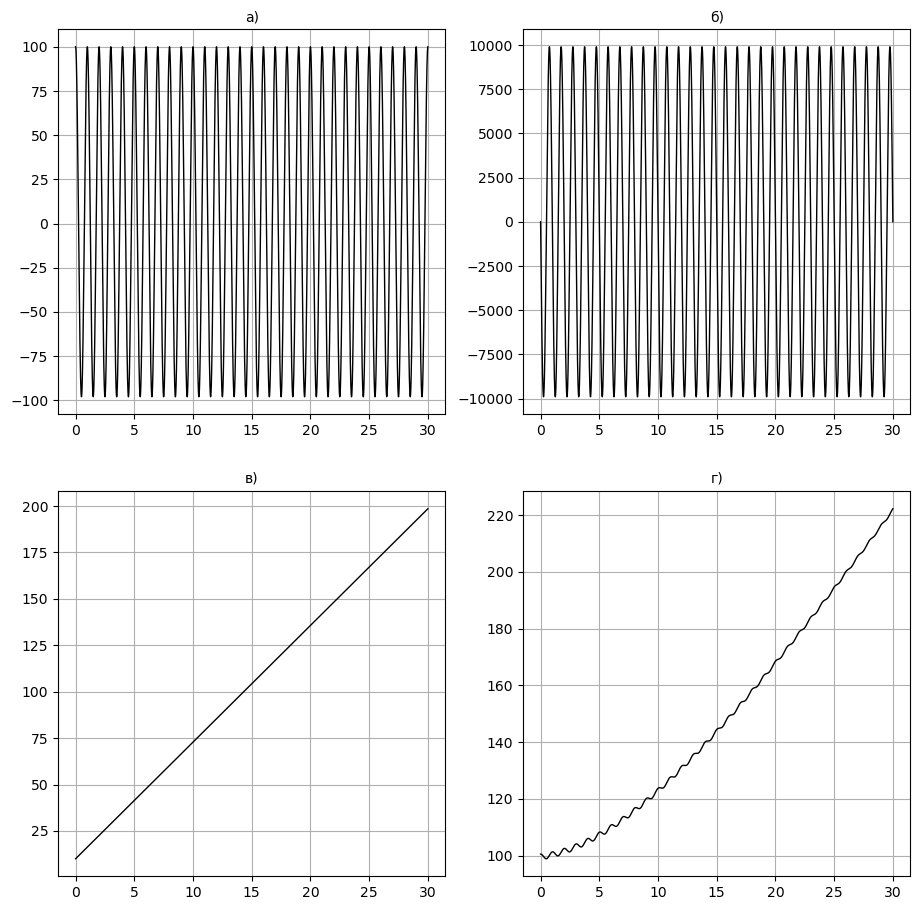

In [5]:
# Ячейка # 5

# визуализация зависимостей проекций скорости и
# модуля скорости заряда
# от времени

fig = plt.figure(figsize=(11, 11))
# визуализация зависимости v_x = v_x(t)
ax = fig.add_subplot(2, 2, 1)
ax.plot(Solv.t[:], Solv.y[1, :] * 10**3, "-k", lw=1)
ax.grid(True)
ax.set_title(r"а)", fontsize=10)

# визуализация зависимости v_y = v_y(t)
ax = fig.add_subplot(2, 2, 2)
ax.plot(Solv.t[:], Solv.y[3, :] * 10**5, "-k", lw=1)
ax.grid(True)
ax.set_title(r"б)", fontsize=10)

# визуализация зависимости v_z = v_z(t)
ax = fig.add_subplot(2, 2, 3)
ax.plot(Solv.t[:], Solv.y[5, :] * 10**3, "-k", lw=1)
ax.grid(True)
ax.set_title(r"в)", fontsize=10)

# визуализация зависимости |v| = |v(t)|
ax = fig.add_subplot(2, 2, 4)
ax.plot(Solv.t, mod_V * 10**3, "-k", lw=1)
ax.grid(True)
ax.set_title(r"г)", fontsize=10)

plt.show()